# Study 07 — When history becomes stale

In the previous study, we saw that a player's true frame-win probability may change over time rather than remain fixed.

That creates a new problem.

Suppose a player is genuinely a **58% frame player** for a long period, then improves and becomes a **64% frame player**.

If we estimate their ability using every frame they have ever played, the old 58% results do not disappear when the player's underlying ability changes. They remain in the historical sample and continue to influence the estimate.

This study asks a deliberately narrow question:

> **How quickly does a career-to-date frame-win estimate recognise a genuine improvement in the player?**

We will keep everything else simple:

- frames are independent;
- the true frame-win probability is 58% before a known change point;
- it becomes 64% after that point;
- there is no momentum;
- there is no parameter uncertainty;
- the estimate always uses the full history available up to that point.

The purpose is not yet to fix the problem. It is simply to show how a large historical sample can make an apparently well-supported estimate slow to respond when the underlying player has genuinely changed.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Set up the change in true ability

We will represent the player's career as a sequence of independent frames.

For an initial block of frames, the player's true probability of winning any given frame is 58%.

At a known change point, that true probability increases immediately to 64%.

The key distinction in this study is between:

- the player's **current true ability**, which changes at the change point; and
- the **career-to-date estimate**, which continues to include all the older 58% frames.

We will start with a reasonably long pre-change history so that the old evidence has some weight.

In [7]:
# True frame-win probabilities before and after the improvement.
p_before = 0.58
p_after = 0.64

# Give the player a substantial history before the change,
# then observe the same number of frames afterwards.
frames_before = 1000
frames_after = 1000

change_point = frames_before
total_frames = frames_before + frames_after

In [8]:
# Each frame has the player's true win probability at that point in time.
true_p = np.concatenate([
    np.full(frames_before, p_before),
    np.full(frames_after, p_after),
])

true_p[:5], true_p[change_point - 2:change_point + 2], true_p[-5:]

(array([0.58, 0.58, 0.58, 0.58, 0.58]),
 array([0.58, 0.58, 0.64, 0.64]),
 array([0.64, 0.64, 0.64, 0.64, 0.64]))

## Simulate the observed frame results

The true probability is not directly observed.

What we actually see is a sequence of wins and losses generated from that probability. Even a genuine 64% player will not win exactly 64 of every 100 frames.

We will simulate one reproducible career so that we can watch the estimate evolve frame by frame.

In [9]:
# Use a fixed seed so this example is reproducible.
rng = np.random.default_rng(7)

# A frame is recorded as 1 for a win and 0 for a loss.
frame_wins = (rng.random(total_frames) < true_p).astype(int)

frame_wins[:10], frame_wins.sum()

(array([0, 0, 0, 1, 1, 0, 1, 0, 0, 1]), np.int64(1217))

## Calculate the career-to-date estimate

After each frame, we estimate the player's frame-win probability using **every result observed so far**.

The estimate after frame \(t\) is:

$$
\hat{p}_t =
\frac{\text{career wins through frame } t}
{\text{frames played through frame } t}
$$

The estimator does not know that the player's true ability changed at frame 1,001.

So after the improvement, the first 1,000 frames remain in the calculation and continue to pull the estimate toward the player's old 58% level.

In [10]:
# Cumulative wins let us calculate the full-history estimate after every frame.
cumulative_wins = np.cumsum(frame_wins)
frames_played = np.arange(1, total_frames + 1)

career_estimate = cumulative_wins / frames_played

career_estimate[change_point - 1], career_estimate[-1]

(np.float64(0.587), np.float64(0.6085))

## Watch the estimate respond after the change

The player's true ability changes immediately, but the career-to-date estimate can only move as new results accumulate.

We can inspect a few points after the change to see how quickly the historical estimate catches up.

In [11]:
# Inspect the estimate at several points before and after the change.
checkpoints = [1000, 1100, 1250, 1500, 1750, 2000]

checkpoint_table = pd.DataFrame({
    "frame": checkpoints,
    "true_p": true_p[np.array(checkpoints) - 1],
    "career_estimate": career_estimate[np.array(checkpoints) - 1],
})

checkpoint_table

,frame,true_p,career_estimate
0,1000,0.58,0.587000
1,1100,0.64,0.597273
2,1250,0.64,0.598400
3,1500,0.64,0.601333
4,1750,0.64,0.610857
5,2000,0.64,0.608500


## Isolate the effect of stale history

The simulated estimate contains two effects at once:

1. old 58% history remains in the calculation; and
2. the observed wins and losses fluctuate randomly.

To see the first effect cleanly, we can calculate what the career-to-date estimate would be **on average** under the known probabilities.

Before the change, that expected estimate is 58%.

After the change, the expected wins from the old 58% period remain permanently in the numerator, while new expected wins accumulate at 64%.

This gives us the underlying path caused by stale history alone.

In [12]:
# Expected cumulative wins under the known true probabilities.
expected_cumulative_wins = np.cumsum(true_p)

# This removes random frame outcomes and isolates the effect of retaining old history.
expected_career_estimate = expected_cumulative_wins / frames_played

expected_career_estimate[np.array(checkpoints) - 1]

array([0.58      , 0.58545455, 0.592     , 0.6       , 0.60571429,
       0.61      ])

## Plot the true ability and the historical estimate

The player's underlying ability jumps immediately from 58% to 64%.

The expected career-to-date estimate cannot jump with it because the old observations remain in the sample.

Plotting the two together makes the lag visible.

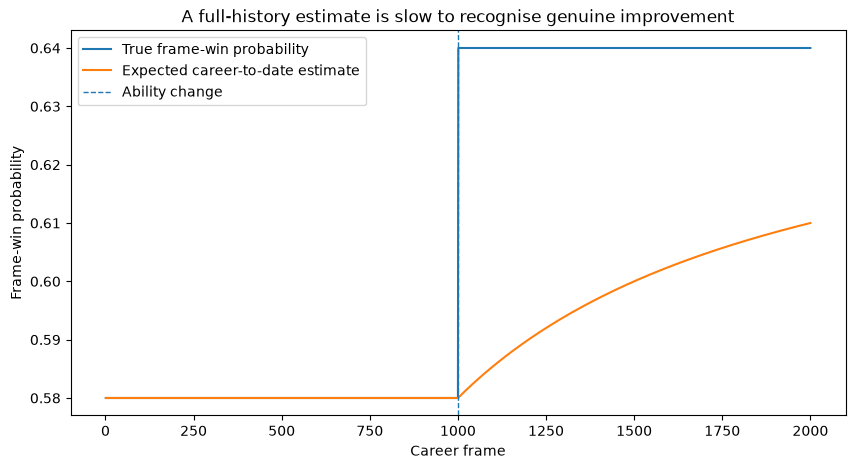

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

# The true ability changes immediately at the known change point.
ax.plot(frames_played, true_p, label="True frame-win probability")

# The full-history estimate adjusts only as new 64% frames accumulate.
ax.plot(
    frames_played,
    expected_career_estimate,
    label="Expected career-to-date estimate",
)

ax.axvline(
    change_point,
    linestyle="--",
    linewidth=1,
    label="Ability change",
)

ax.set_xlabel("Career frame")
ax.set_ylabel("Frame-win probability")
ax.set_title("A full-history estimate is slow to recognise genuine improvement")
ax.legend()

plt.show()

## How much new evidence is needed?

The old observations never lose weight in a career-to-date estimate.

After \(n\) new frames at 64%, the expected estimate is:

$$
\hat{p}(n)
=
\frac{1000(0.58) + n(0.64)}
{1000 + n}
$$

We can use this to ask a practical question:

> How many frames at the player's new 64% level are needed before the full-history estimate reaches 63%?

That is still one percentage point below the player's actual current ability.

In [15]:
# Find the first number of post-change frames for which the
# expected full-history estimate reaches at least 63%.
target = 0.63

post_change_frames = np.arange(1, 10001)

expected_after_change = (
    frames_before * p_before + post_change_frames * p_after
) / (
    frames_before + post_change_frames
)

frames_to_target = post_change_frames[
    np.argmax(expected_after_change >= target)
]

frames_to_target

np.int64(5000)

## The old sample can remain influential for a long time

The result is striking.

After 1,000 frames as a 58% player, the player must then perform at their new 64% level for **5,000 additional frames** before the expected career-to-date estimate reaches 63%.

At that point:

- 1,000 old frames came from the 58% version of the player;
- 5,000 new frames came from the 64% version;
- the estimate is still one percentage point below the player's current true ability.

The problem is not a lack of data.

There are now 6,000 frames in the sample.

The problem is that the estimator treats observations from the player's old level as if they are still equally informative about the player they are today.

## Add the observed career estimate

The expected path shows the stale-history effect cleanly, but real data would not follow that smooth curve.

Observed wins and losses fluctuate around expectation.

We can therefore compare three things:

- the player's true current ability;
- the expected career-to-date estimate caused by retaining all history;
- the career-to-date estimate from our simulated results.

The simulated estimate should move noisily around the expected path rather than immediately tracking the new 64% level.

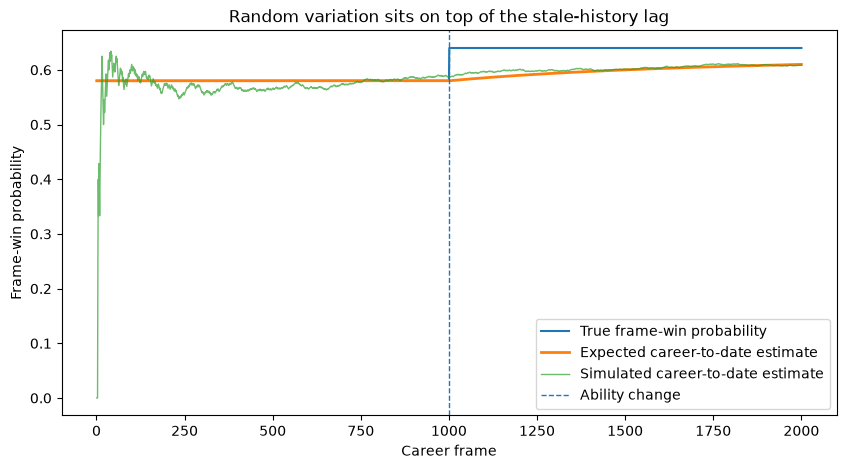

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))

# Current underlying ability.
ax.plot(
    frames_played,
    true_p,
    label="True frame-win probability",
)

# Average path implied purely by retaining the old history.
ax.plot(
    frames_played,
    expected_career_estimate,
    linewidth=2,
    label="Expected career-to-date estimate",
)

# What we would actually observe from one simulated sequence of results.
ax.plot(
    frames_played,
    career_estimate,
    linewidth=1,
    alpha=0.7,
    label="Simulated career-to-date estimate",
)

ax.axvline(
    change_point,
    linestyle="--",
    linewidth=1,
    label="Ability change",
)

ax.set_xlabel("Career frame")
ax.set_ylabel("Frame-win probability")
ax.set_title("Random variation sits on top of the stale-history lag")
ax.legend()

plt.show()

## Focus on the period around the improvement

The first few career frames naturally produce an unstable estimate because almost no data has yet been observed.

That is a different problem from the one being studied here.

To make the stale-history effect easier to see, we will focus the chart on the later part of the career, when the player already has a substantial historical sample.

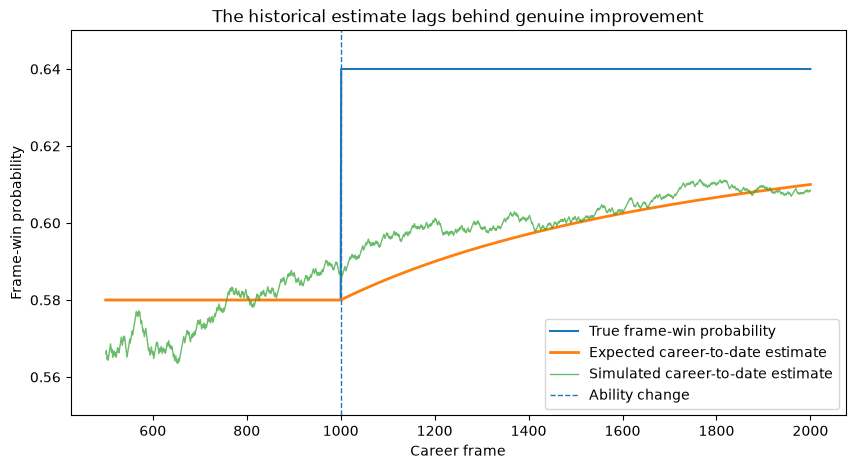

In [20]:
# Focus on the mature part of the career so early small-sample noise
# does not obscure the behaviour around the ability change.
focus_start = 500
focus_slice = slice(focus_start - 1, None)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    frames_played[focus_slice],
    true_p[focus_slice],
    label="True frame-win probability",
)

ax.plot(
    frames_played[focus_slice],
    expected_career_estimate[focus_slice],
    linewidth=2,
    label="Expected career-to-date estimate",
)

ax.plot(
    frames_played[focus_slice],
    career_estimate[focus_slice],
    linewidth=1,
    alpha=0.7,
    label="Simulated career-to-date estimate",
)

ax.axvline(
    change_point,
    linestyle="--",
    linewidth=1,
    label="Ability change",
)

ax.set_ylim(0.55, 0.65)
ax.set_xlabel("Career frame")
ax.set_ylabel("Frame-win probability")
ax.set_title("The historical estimate lags behind genuine improvement")
ax.legend()

plt.show()

## Why does the estimate lag?

The full-history estimate is a mixture of observations from two different versions of the player.

After \(n\) new frames at 64%, the original 1,000 frames still make up:

$$
\frac{1000}{1000+n}
$$

of the total sample.

So the gap between the player's current 64% ability and the expected career estimate is determined directly by how much of the sample still comes from the old 58% period.

A large historical sample therefore creates inertia: the more old evidence we retain, the more new evidence is needed to overcome it.

In [21]:
# Show how much of the full-history sample still comes from
# the player's old 58% period as new evidence accumulates.
new_frame_counts = np.array([0, 100, 250, 500, 1000, 5000])

old_history_weight = frames_before / (frames_before + new_frame_counts)

expected_estimates = (
    frames_before * p_before + new_frame_counts * p_after
) / (
    frames_before + new_frame_counts
)

lag_table = pd.DataFrame({
    "new_64pct_frames": new_frame_counts,
    "old_history_share": old_history_weight,
    "expected_estimate": expected_estimates,
    "gap_to_current_ability": p_after - expected_estimates,
})

lag_table

,new_64pct_frames,old_history_share,expected_estimate,gap_to_current_ability
0,0,1.000000,0.580000,0.060000
1,100,0.909091,0.585455,0.054545
2,250,0.800000,0.592000,0.048000
3,500,0.666667,0.600000,0.040000
4,1000,0.500000,0.610000,0.030000
5,5000,0.166667,0.630000,0.010000


## Conclusion

A large historical sample can make an estimate look stable while making it slow to recognise a genuine change in the player.

In this example, the player spends 1,000 frames as a 58% frame player and then immediately becomes a 64% frame player.

The career-to-date estimate retains every old result.

As a result:

- after 500 new frames at 64%, the expected estimate is only 60%;
- after 1,000 new frames at 64%, it is only 61%;
- it takes 5,000 new frames at 64% before it reaches 63%.

This lag is not caused by momentum, dependence between frames, parameter uncertainty, or bad luck in the simulated results.

It exists even when we work entirely with expected values.

The cause is simply that the historical estimator does not forget. Results generated by the player's old 58% ability continue to receive the same weight as results generated by their current 64% ability.

That exposes an important distinction:

> **A large sample can give us a precise estimate of historical average performance without giving us a good estimate of current performance.**

More data is therefore not automatically better when the process generating the data has changed.

This study deliberately stops at identifying that problem. It does not yet ask how old observations should be discounted or discarded.